# Comparing NRMSE


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.transforms as transforms

# Compare by model type

In [21]:
def plot_nrmse_confint(model_type, dataset):

    confint_nofull = pd.read_csv(
        f"../data/model_results/metrics/{model_type}_confint_{dataset}.csv"
    )
    confint_nofull["canton"] = confint_nofull["canton"].astype(str)

    confint_full = pd.read_csv(
        f"../data/model_results/metrics/{model_type}_confint_{dataset}_full.csv"
    )
    confint_full["canton"] = confint_full["canton"].astype(str)

    x = np.arange(len(confint_full))
    
    fig, ax = plt.subplots(figsize=(18, 6))

    cap_width = 0.2

    for i, row in confint_nofull.iterrows():

        mean_col = "mean"
        lower_col = "lower"
        upper_col = "upper"
        
        ax.vlines(
            x[i],
            row[lower_col],
            row[upper_col],
            color="#009E73",
            linewidth=4,
            linestyles="--"
        )

        ax.hlines(
            row[lower_col],
            x[i]-cap_width,
            x[i]+cap_width,
            color="#009E73",
            linestyles="--",
            linewidth=4,
        )

        ax.hlines(
            row[upper_col],
            x[i]-cap_width,
            x[i]+cap_width,
            color="#009E73",
            linestyles="--",
            linewidth=4,
        )

        ax.scatter(
            x[i],
            row[mean_col],
            color="#009E73",
            marker="o",
            s=50,
            zorder=4
        )

    for i, row in confint_full.iterrows():

        mean_col = "mean"
        lower_col = "lower"
        upper_col = "upper"

        x_full = x[i] + 0.8

        ax.vlines(
            x_full,
            row[lower_col],
            row[upper_col],
            color="#D55E00",
            linewidth=4
        )

        ax.hlines(row[lower_col], x_full-cap_width, x_full+cap_width, color="#D55E00", linewidth=4)
        ax.hlines(row[upper_col], x_full-cap_width, x_full+cap_width, color="#D55E00", linewidth=4)

        ax.scatter(
            x_full,
            row[mean_col],
            color="#D55E00",
            s=50,
            zorder=3
        )

    ax.set_xticks(x + 0.4)
    ax.set_xticklabels(confint_full["canton"], rotation=90, ha="right", fontweight="bold", fontsize = 14)
    dx = 4 / 72.0  
    offset = transforms.ScaledTranslation(dx, 0, fig.dpi_scale_trans)

    for label in ax.get_xticklabels():
        label.set_transform(label.get_transform() + offset)

    style_handles = [
        Line2D([0], [0], color="#009E73", linestyle="-", label="Individual model", linewidth=4),
        Line2D([0], [0], color="#D55E00", linestyle=":", label="Global model", linewidth=4),
    ]


    ax.set_ylabel("NRMSE", fontsize = 24, fontweight="bold")
    ax.set_xlabel("Municipality", fontsize = 24, fontweight="bold")
    ax.set_ylim([0, 8.5])
    ax.legend(handles=style_handles, fontsize=20, loc="upper right")
    ax.set_yticklabels(range(0, 9), fontsize = 22, fontweight="bold")
    plt.grid(axis='y', color = 'gray', linestyle = '--', linewidth = 0.5)
    plt.tight_layout()
    plt.show()

## RF

C:\Windows\Temp\ipykernel_34448\1554899361.py:106: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(range(0, 9), fontsize = 22, fontweight="bold")


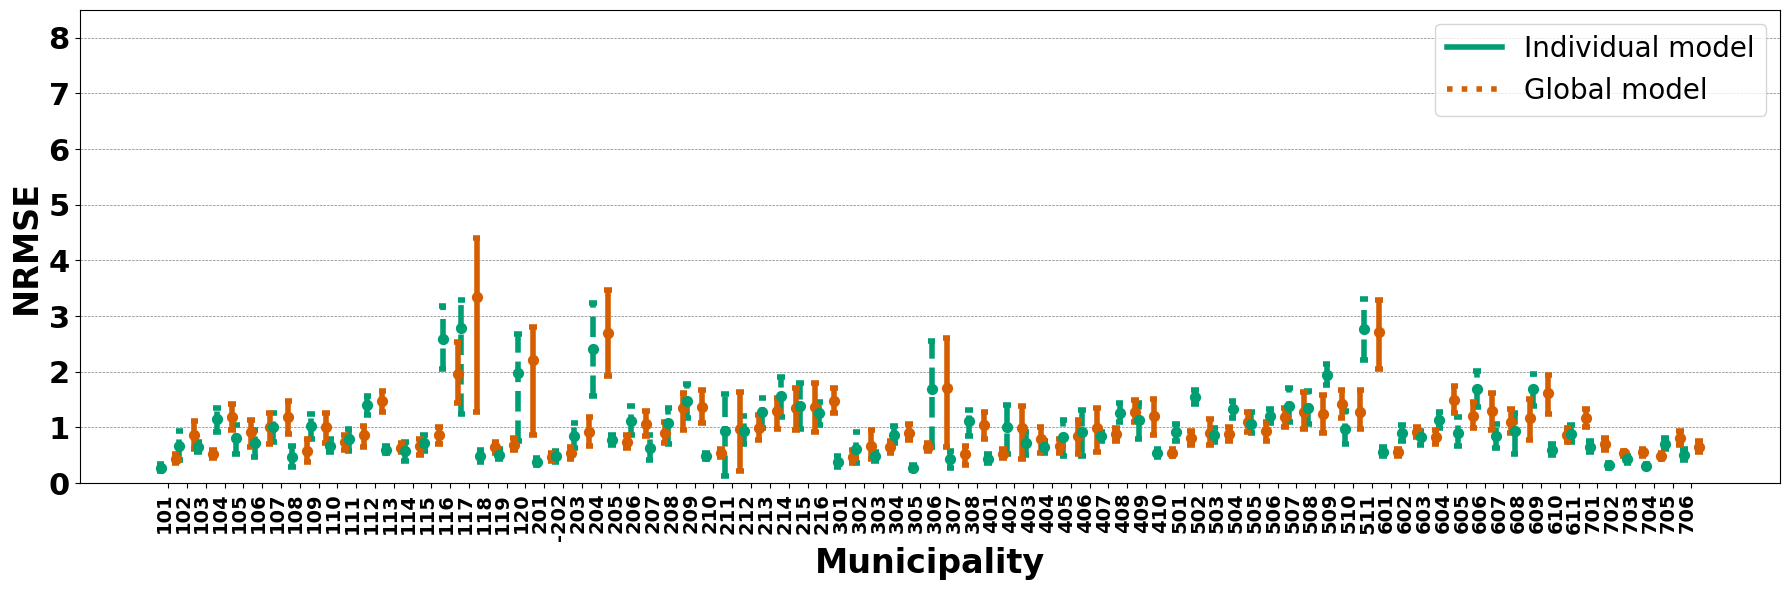

In [22]:
plot_nrmse_confint("rf", "train")

C:\Windows\Temp\ipykernel_34448\2666539661.py:105: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(range(0, 9), fontsize = 22, fontweight="bold")


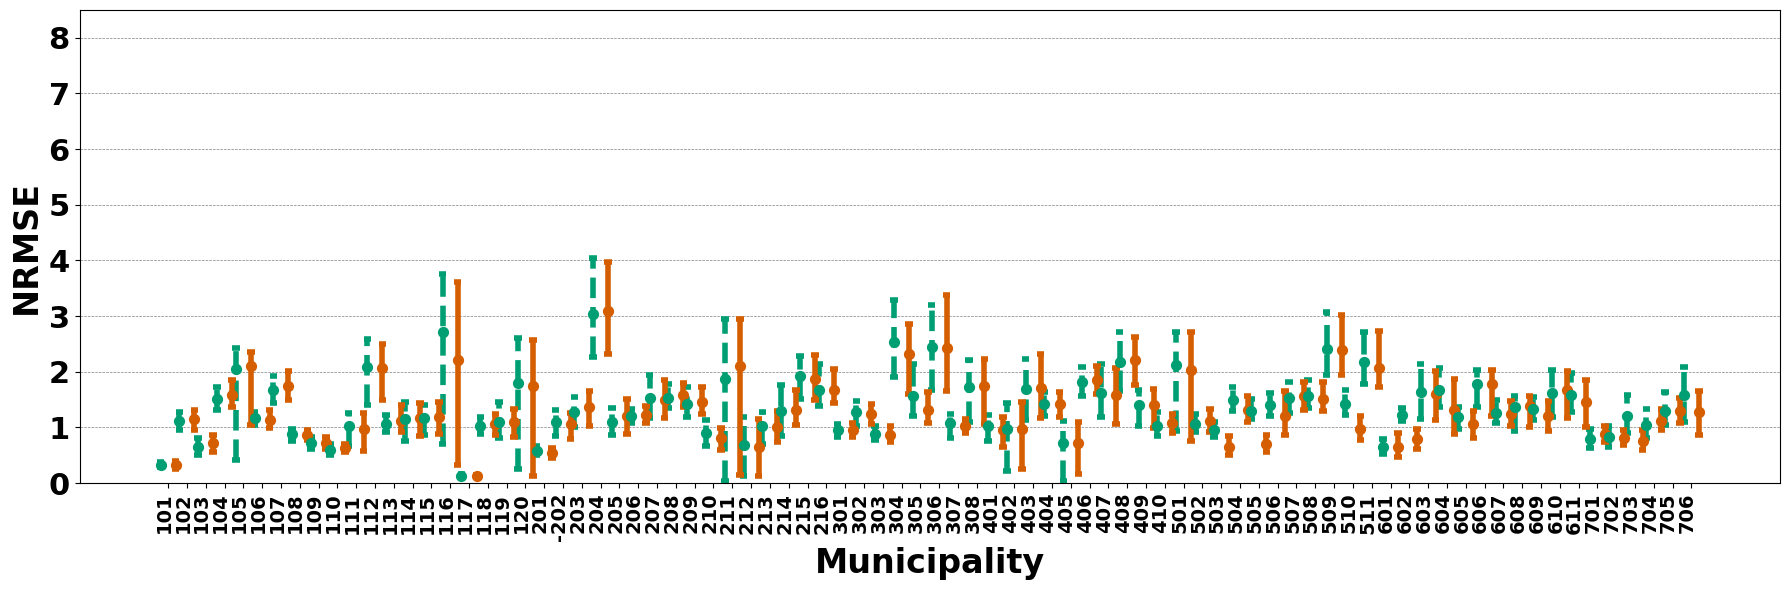

C:\Windows\Temp\ipykernel_34448\2666539661.py:105: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(range(0, 9), fontsize = 22, fontweight="bold")


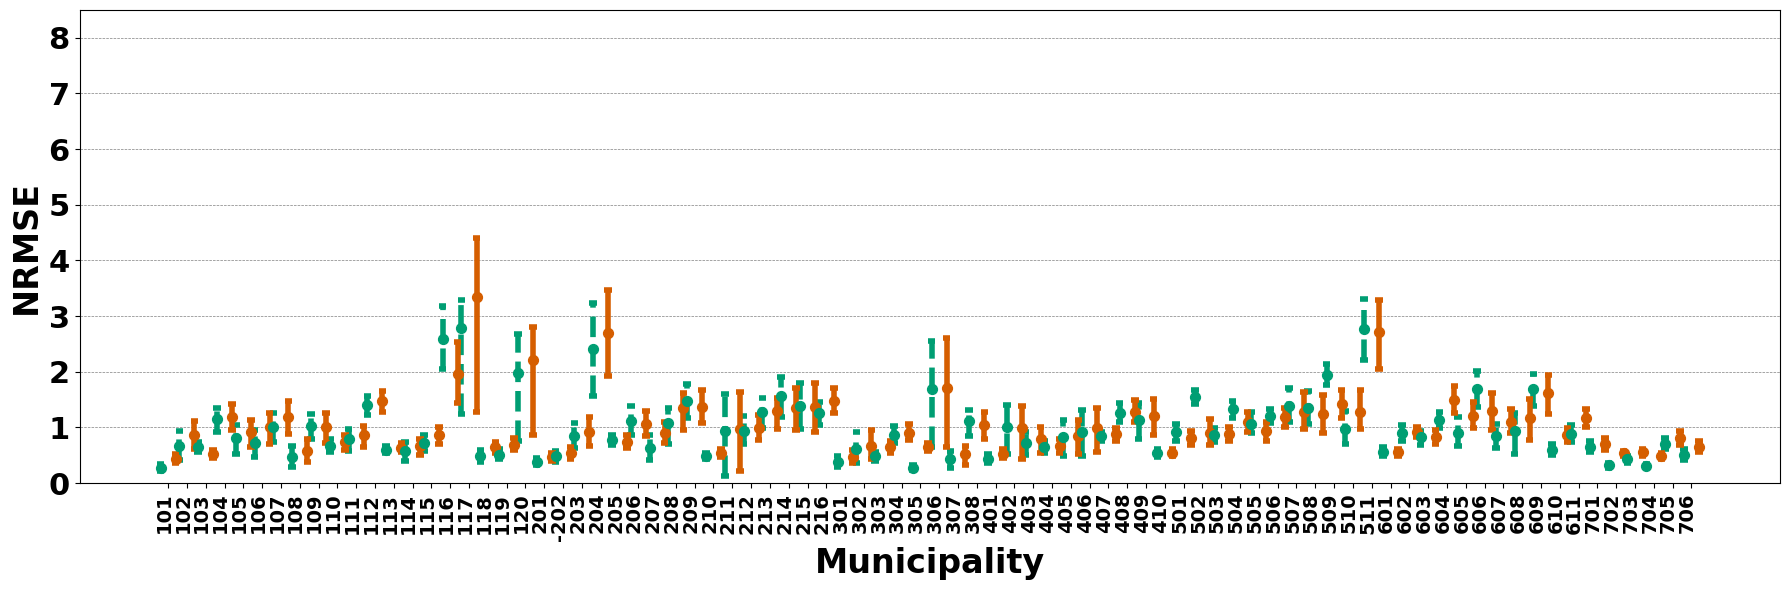

In [3]:
plot_nrmse_confint("rf", "test")
plot_nrmse_confint("rf", "train")

## XGB

C:\Windows\Temp\ipykernel_34448\2666539661.py:105: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(range(0, 9), fontsize = 22, fontweight="bold")


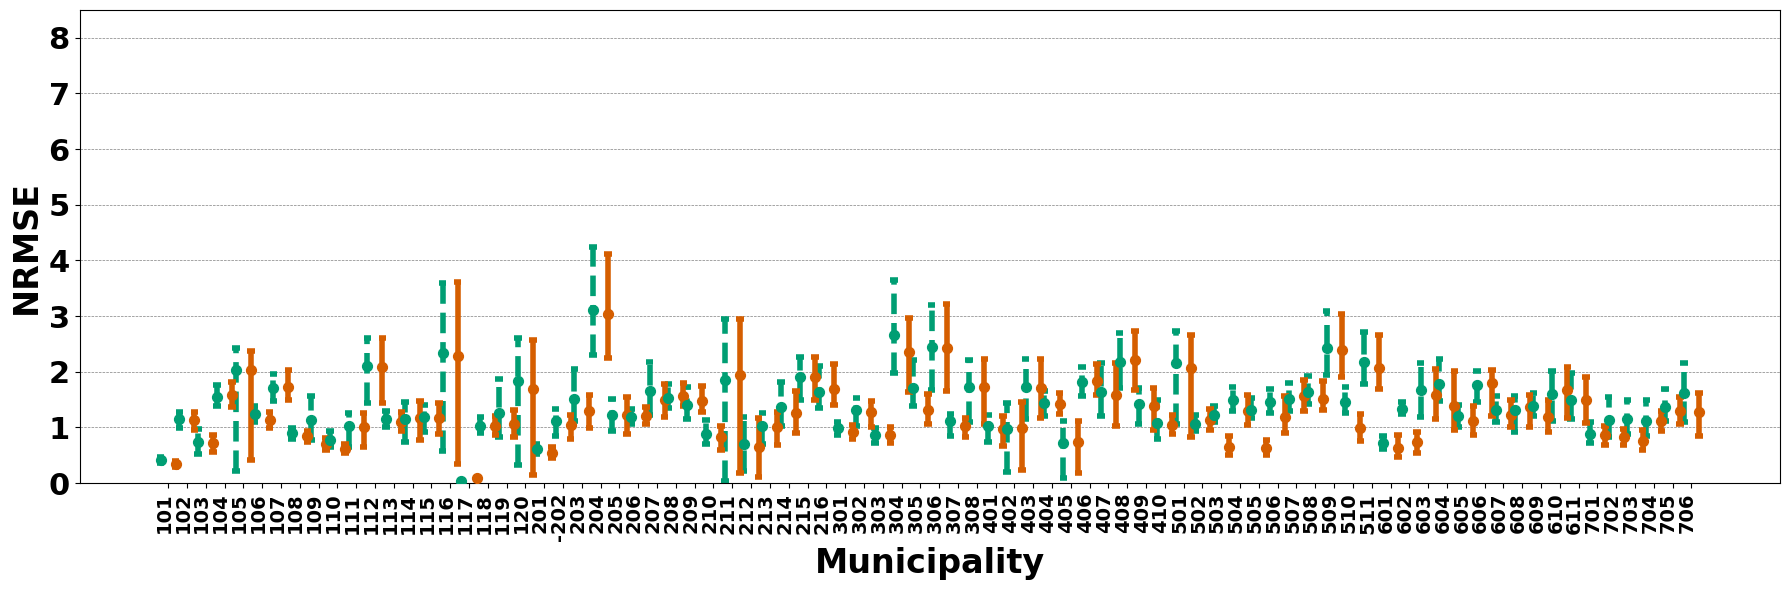

C:\Windows\Temp\ipykernel_34448\2666539661.py:105: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(range(0, 9), fontsize = 22, fontweight="bold")


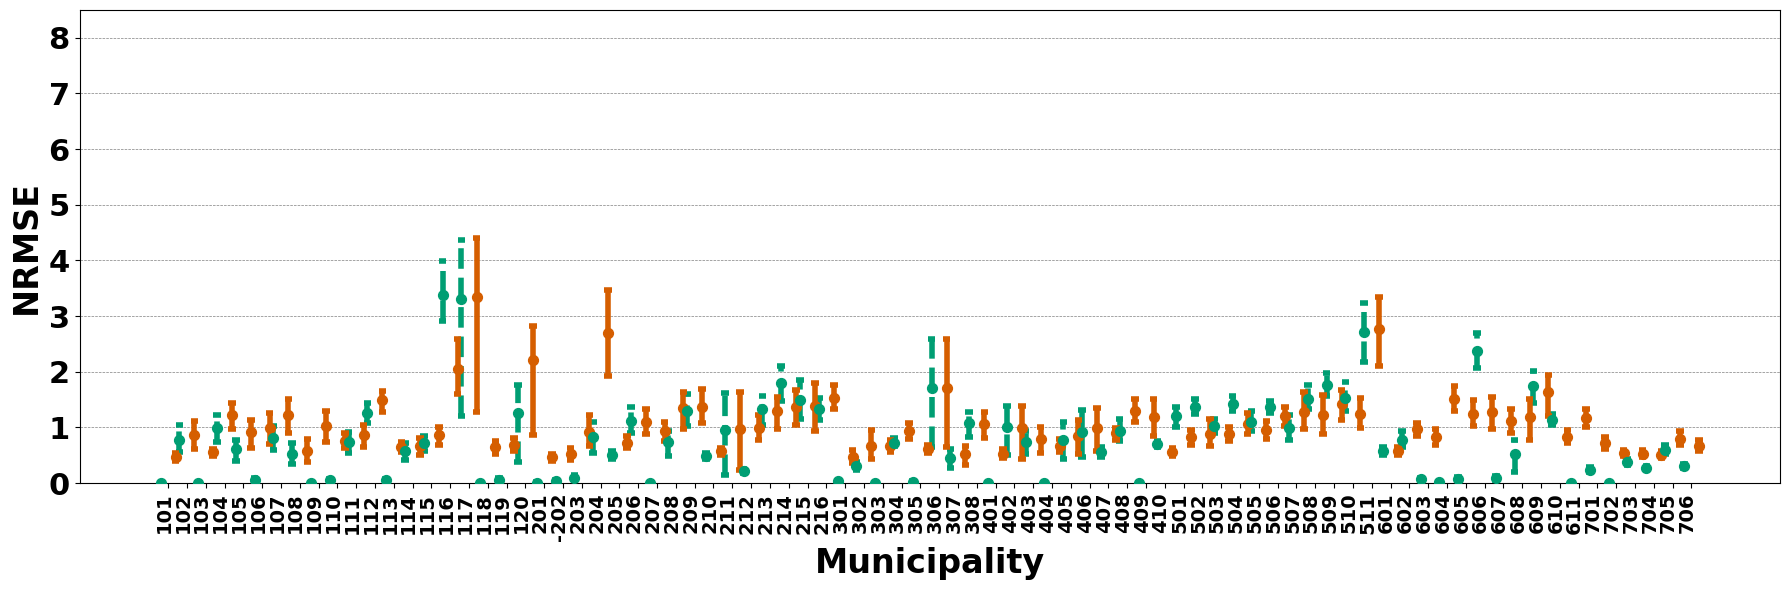

In [4]:
plot_nrmse_confint("xgb", "test")
plot_nrmse_confint("xgb", "train")

## HRF

C:\Windows\Temp\ipykernel_34448\2666539661.py:105: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(range(0, 9), fontsize = 22, fontweight="bold")


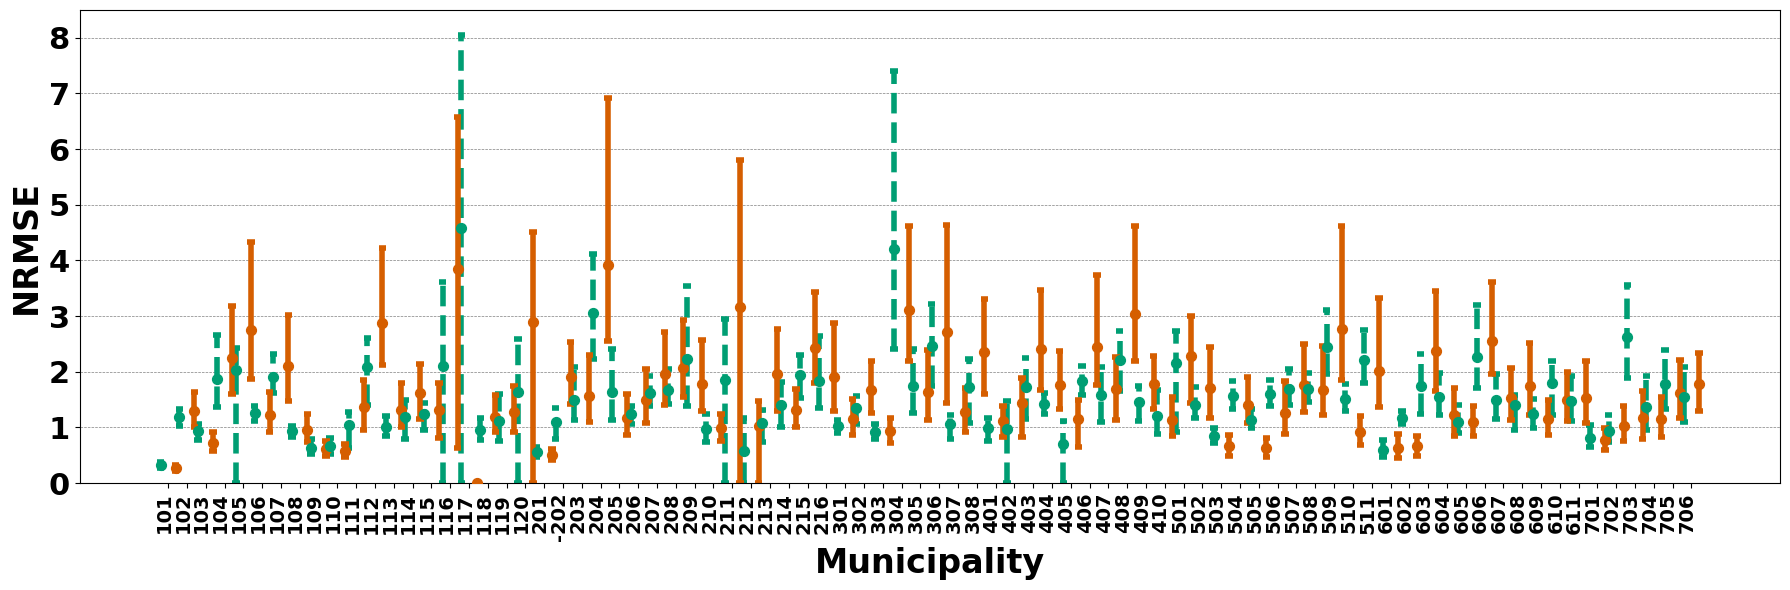

C:\Windows\Temp\ipykernel_34448\2666539661.py:105: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(range(0, 9), fontsize = 22, fontweight="bold")


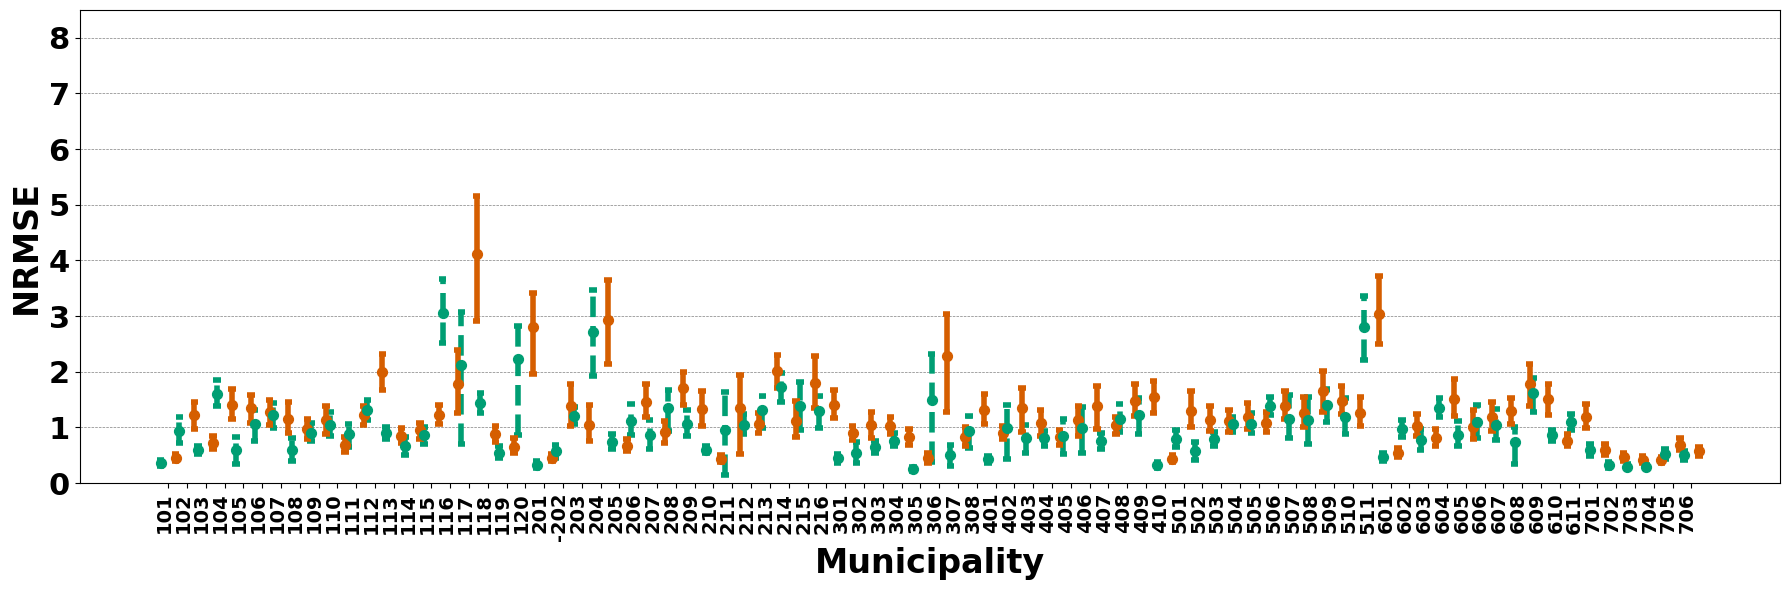

In [5]:
plot_nrmse_confint("hrf", "test")
plot_nrmse_confint("hrf", "train")

## HXGB

C:\Windows\Temp\ipykernel_34448\2666539661.py:105: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(range(0, 9), fontsize = 22, fontweight="bold")


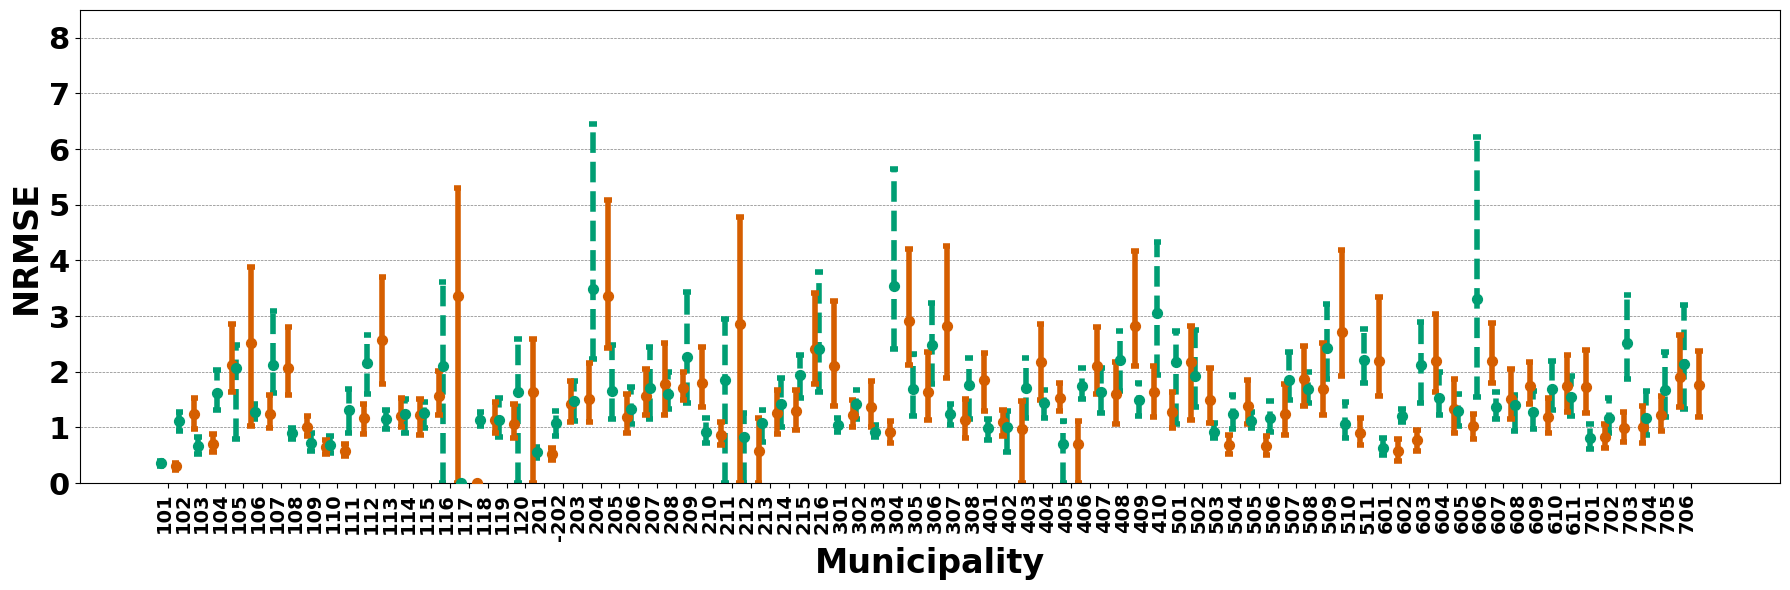

C:\Windows\Temp\ipykernel_34448\2666539661.py:105: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(range(0, 9), fontsize = 22, fontweight="bold")


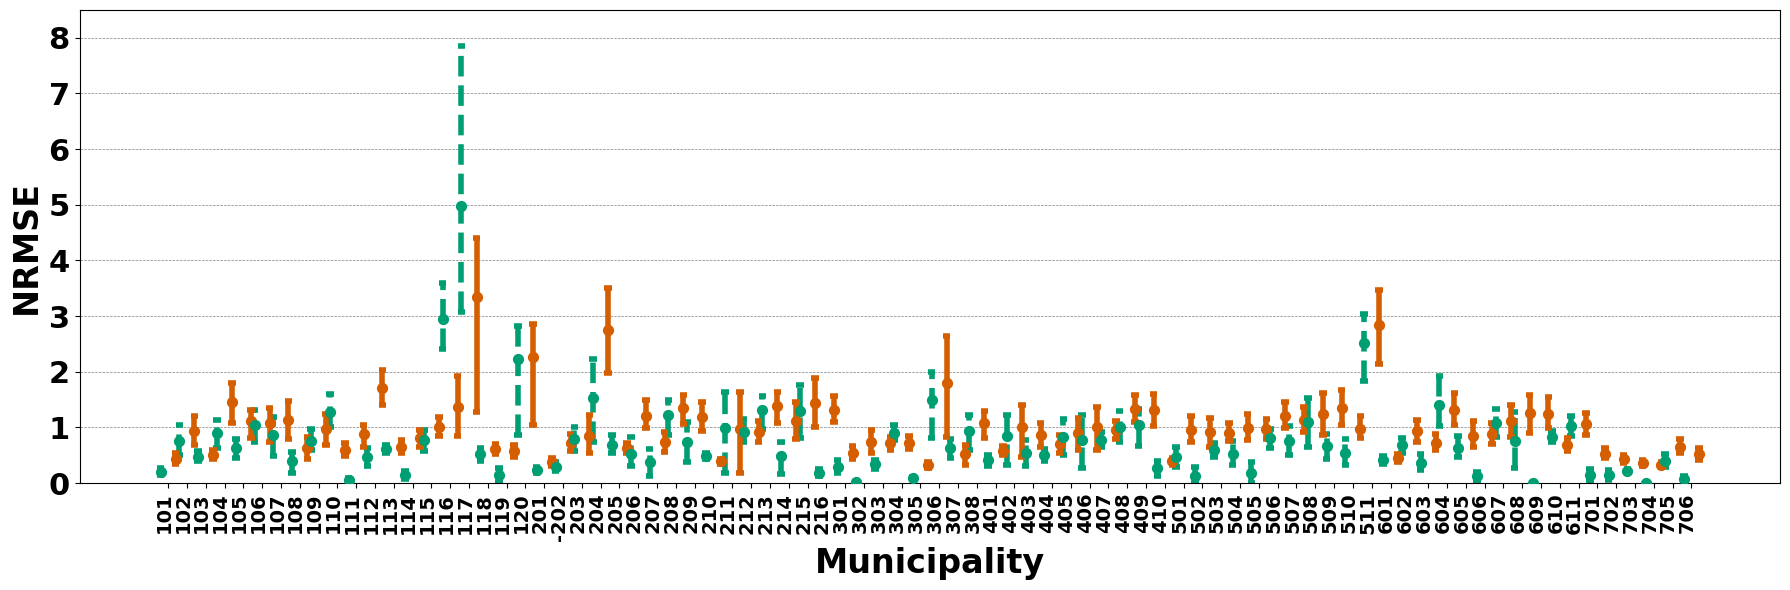

In [6]:
plot_nrmse_confint("hxgb", "test")
plot_nrmse_confint("hxgb", "train")

# Compare the best models

In [5]:
model_types = ["rf", "xgb", "hrf", "hxgb"]
points = ["nrmse", "mean", "lower", "upper"]

for model_type in model_types:
    confint = pd.read_csv(f"../data/model_results/metrics/{model_type}_confint_test.csv")
    confint_nofull = confint[confint["canton"] != "full"].reset_index(drop=True)
    confint_nofull["canton"] = confint_nofull["canton"].astype(str)
    confint_nofull.rename(
        columns={
            "nrmse": f"nrmse_{model_type}",
            "mean": f"mean_{model_type}",
            "lower": f"lower_{model_type}",
            "upper": f"upper_{model_type}",
        },
        inplace=True,
    )

    confint_full = pd.read_csv(f"../data/model_results/metrics/{model_type}_confint_test_full.csv")
    confint_full["canton"] = confint_full["canton"].astype(str)
    confint_full.rename(
        columns={
            "nrmse": f"nrmse_{model_type}",
            "mean": f"mean_{model_type}",
            "lower": f"lower_{model_type}",
            "upper": f"upper_{model_type}",
        },
        inplace=True,
    )

    if model_type == "rf":
        confint_all_models_ind_test = confint_nofull
        confint_all_models_full_test = confint_full
    else:
        confint_all_models_ind_test = pd.merge(
            confint_all_models_ind_test,
            confint_nofull,
            on="canton",
            how="inner",
        )
        confint_all_models_full_test = pd.merge(
            confint_all_models_full_test,
            confint_full,
            on="canton",
            how="inner",
        )

for point in points:
    model_cols = [f"{point}_{model_type}" for model_type in model_types]
    confint_all_models_ind_test[f"best_{point}_model"] = confint_all_models_ind_test[model_cols].idxmin(axis=1)
    confint_all_models_full_test[f"best_{point}_model"] = confint_all_models_full_test[model_cols].idxmin(axis=1)

In [51]:
confint_all_models_ind_test.to_csv("../data/model_results/metrics/best_model_ind_confint_test.csv", index=False)
confint_all_models_full_test.to_csv("../data/model_results/metrics/best_model_full_confint_test.csv", index=False)

In [52]:
model_types = ["rf", "xgb", "hrf", "hxgb"]
points = ["nrmse", "mean", "lower", "upper"]

for model_type in model_types:
    confint = pd.read_csv(f"../data/model_results/metrics/{model_type}_confint_train.csv")
    confint_nofull = confint[confint["canton"] != "full"].reset_index(drop=True)
    confint_nofull["canton"] = confint_nofull["canton"].astype(str)
    confint_nofull.rename(
        columns={
            "nrmse": f"nrmse_{model_type}",
            "mean": f"mean_{model_type}",
            "lower": f"lower_{model_type}",
            "upper": f"upper_{model_type}",
        },
        inplace=True,
    )

    confint_full = pd.read_csv(f"../data/model_results/metrics/{model_type}_confint_train_full.csv")
    confint_full["canton"] = confint_full["canton"].astype(str)
    confint_full.rename(
        columns={
            "nrmse": f"nrmse_{model_type}",
            "mean": f"mean_{model_type}",
            "lower": f"lower_{model_type}",
            "upper": f"upper_{model_type}",
        },
        inplace=True,
    )

    if model_type == "rf":
        confint_all_models_ind_train = confint_nofull
        confint_all_models_full_train = confint_full
    else:
        confint_all_models_ind_train = pd.merge(
            confint_all_models_ind_train,
            confint_nofull,
            on="canton",
            how="inner",
        )
        confint_all_models_full_train = pd.merge(
            confint_all_models_full_train,
            confint_full,
            on="canton",
            how="inner",
        )

for point in points:
    model_cols = [f"{point}_{model_type}" for model_type in model_types]
    confint_all_models_ind_train[f"best_{point}_model"] = confint_all_models_ind_train[model_cols].idxmin(axis=1)
    confint_all_models_full_train[f"best_{point}_model"] = confint_all_models_full_train[model_cols].idxmin(axis=1)

In [53]:
confint_all_models_ind_train.to_csv("../data/model_results/metrics/best_model_ind_confint_train.csv", index=False)
confint_all_models_full_train.to_csv("../data/model_results/metrics/best_model_full_confint_train.csv", index=False)

## Plot

In [14]:
def plot_best_nrmse_confint(dataset):
    conf_test_nofull = pd.read_csv(
            f"../data/model_results/metrics/best_model_ind_confint_test.csv"
        )
    conf_test_nofull["canton"] = conf_test_nofull["canton"].astype(str)
    conf_test_full = pd.read_csv(
        f"../data/model_results/metrics/best_model_full_confint_test.csv"
    )
    conf_test_full["canton"] = conf_test_full["canton"].astype(str)

    if dataset == "train":
        confint_nofull = pd.read_csv(
            f"../data/model_results/metrics/best_model_ind_confint_train.csv"
        )
        confint_nofull["canton"] = confint_nofull["canton"].astype(str)

        confint_full = pd.read_csv(
            f"../data/model_results/metrics/best_model_full_confint_train.csv"
        )
        confint_full["canton"] = confint_full["canton"].astype(str)

        confint_nofull["best_mean_model"] = conf_test_nofull["best_mean_model"]
        confint_full["best_mean_model"] = conf_test_full["best_mean_model"]

    elif dataset == "test":
        confint_full = conf_test_full
        confint_nofull = conf_test_nofull

    x = np.arange(len(confint_full))

    fig, ax = plt.subplots(figsize=(16, 6))

    cap_width = 0.2

    for i, row in confint_nofull.iterrows():

        mean_col = row["best_mean_model"]
        lower_col = mean_col.replace("mean_", "lower_")
        upper_col = mean_col.replace("mean_", "upper_")
        
        ax.vlines(
            x[i],
            row[lower_col],
            row[upper_col],
            color="#009E73",
            linewidth=4,
            linestyles="--"
        )

        ax.hlines(
            row[lower_col],
            x[i]-cap_width,
            x[i]+cap_width,
            color="#009E73",
            linestyles="--",
            linewidth=4
        )

        ax.hlines(
            row[upper_col],
            x[i]-cap_width,
            x[i]+cap_width,
            color="#009E73",
            linestyles="--",
            linewidth=4
        )

        ax.scatter(
            x[i],
            row[mean_col],
            color="#009E73",
            marker="o",
            s=50,
            zorder=4
        )

    for i, row in confint_full.iterrows():

        mean_col = row["best_mean_model"]
        lower_col = mean_col.replace("mean_", "lower_")
        upper_col = mean_col.replace("mean_", "upper_")

        x_full = x[i] + 0.8

        ax.vlines(
            x_full,
            row[lower_col],
            row[upper_col],
            color="#D55E00",
            linewidth=4
        )

        ax.hlines(row[lower_col], x_full-cap_width, x_full+cap_width, color="#D55E00", linewidth=4)
        ax.hlines(row[upper_col], x_full-cap_width, x_full+cap_width, color="#D55E00", linewidth=4)

        ax.scatter(
            x_full,
            row[mean_col],
            color="#D55E00",
            s=50,
            zorder=3
        )

    ax.set_xticks(x + 0.4)
    ax.set_xticklabels(confint_full["canton"], rotation=90, ha="right", fontsize = 12, fontweight="bold")
    dx = 4 / 72.0  
    offset = transforms.ScaledTranslation(dx, 0, fig.dpi_scale_trans)

    for label in ax.get_xticklabels():
        label.set_transform(label.get_transform() + offset)

    style_handles = [
        Line2D([0], [0], color="#009E73", linestyle="-", label="Individual model"),
        Line2D([0], [0], color="#D55E00", linestyle=":", label="Global model"),
    ]
        
    ax.set_ylabel("NRMSE", fontsize = 20, fontweight="bold")
    ax.set_xlabel("Municipality", fontsize = 20, fontweight="bold")
    ax.set_ylim([0, 8])
    ax.set_yticklabels(range(0, 9), fontsize = 18, fontweight="bold")
    ax.legend(handles=style_handles, fontsize=14, loc="upper right")

    plt.grid(axis='y', color = 'gray', linestyle = '--', linewidth = 0.5)
    plt.tight_layout()
    plt.show()

C:\Windows\Temp\ipykernel_34448\1442883836.py:120: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(range(0, 9), fontsize = 18, fontweight="bold")


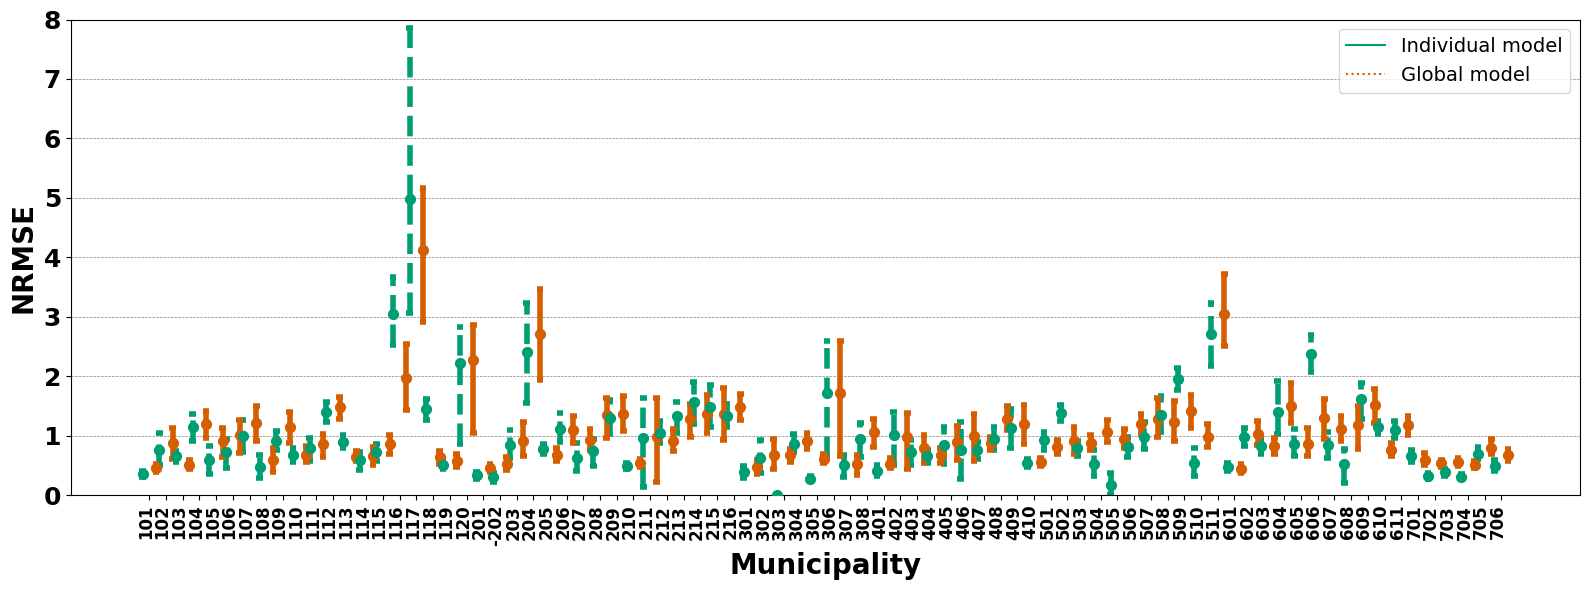

In [16]:
plot_best_nrmse_confint("train")

C:\Windows\Temp\ipykernel_34448\1319436755.py:120: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(range(0, 9), fontsize = 18, fontweight="bold")


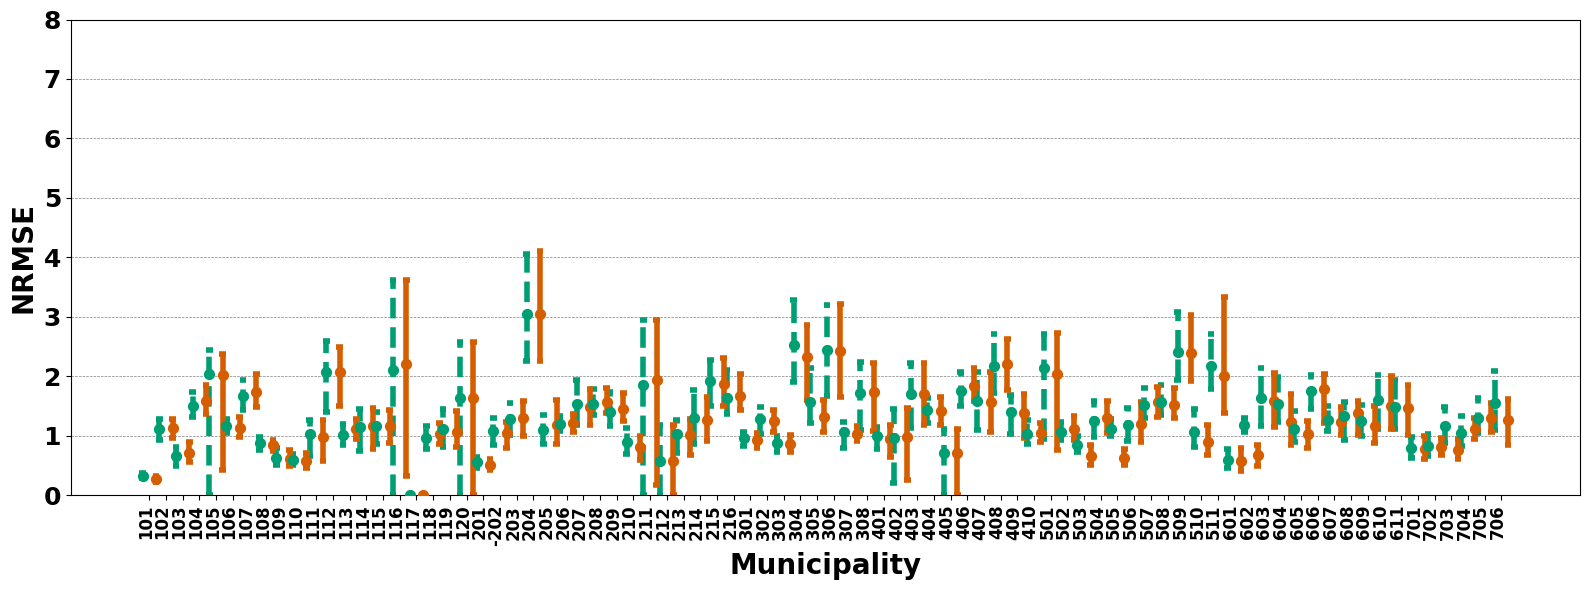

C:\Windows\Temp\ipykernel_34448\1319436755.py:120: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(range(0, 9), fontsize = 18, fontweight="bold")


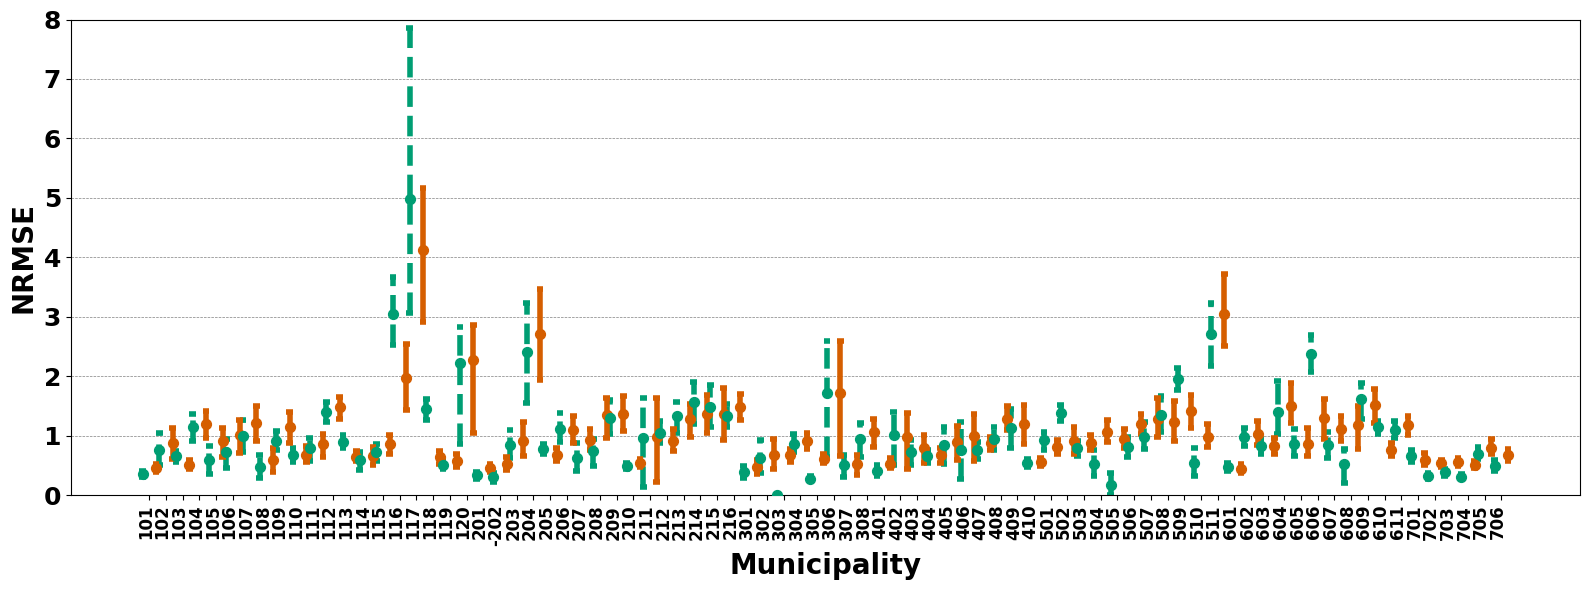

In [ ]:
plot_best_nrmse_confint("train")

# Computation Times

In [15]:
rf_full = pd.read_csv('../data/model_results/comp_time/rf_comp_time_full.csv')
rf_nofull = pd.read_csv('../data/model_results/comp_time/rf_comp_time_nofull.csv')
xgb_full = pd.read_csv('../data/model_results/comp_time/xgb_comp_time_full.csv')
xgb_nofull = pd.read_csv('../data/model_results/comp_time/xgb_comp_time_nofull.csv')
hrf_full = pd.read_csv('../data/model_results/comp_time/hrf_comp_time_full.csv')
hrf_nofull = pd.read_csv('../data/model_results/comp_time/hrf_comp_time_nofull.csv')
hxgb_full = pd.read_csv('../data/model_results/comp_time/hxgb_comp_time_full.csv')
hxgb_nofull = pd.read_csv('../data/model_results/comp_time/hxgb_comp_time_nofull.csv')

## RF

In [12]:
rf_full["time"][0]

7048.990744399955

In [10]:
rf_nofull["time"].sum()

3698.8600000000006

## XGB

In [13]:
xgb_full["time"][0]

1045.0822414999711

In [16]:
xgb_nofull["time"].sum()

12365.83

## HRF

In [17]:
hrf_full["time"][0]

2708.6805581999943

In [19]:
hrf_nofull["time"].sum()

4074.1100000000006

## HXGB

In [20]:
hxgb_full["time"][0]

1298.470086199988

In [21]:
hxgb_nofull["time"].sum()

8524.11